# **Detecting Exoplanet Transits from Stellar Light Curves**
# _by team CYGNUS X_

## _Libraries we will be Using_ -->

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as sp
import os

## _Reading the csv file using Pandas_ -->

In [19]:
df = pd.read_csv("binary_exoplanet_dataset.csv")

In [20]:
df

,case_id,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,...,t_990,t_991,t_992,t_993,t_994,t_995,t_996,t_997,t_998,t_999
0,0,1.001467,0.974578,0.990939,1.005583,1.016866,0.978667,0.999666,1.002929,0.985294,...,0.983364,0.968474,0.940799,1.007124,0.952824,0.968135,0.986389,0.955035,0.995408,0.969572
1,1,0.991383,0.997078,1.002858,1.010323,1.009412,0.995447,0.996305,1.001701,1.009693,...,0.989757,0.999948,0.994257,0.996659,0.997532,0.994892,1.007236,1.002185,1.004162,0.985335
2,2,1.005812,1.004390,0.997610,1.000661,1.015333,1.013189,0.999197,1.012301,1.003571,...,1.058821,1.079871,1.051871,1.056161,1.040972,1.071868,1.082333,1.059451,1.078758,1.070366
3,3,0.995194,1.007336,0.990161,1.007508,1.008834,0.985094,1.012382,1.003648,0.995286,...,1.003461,0.997333,0.976115,0.995185,0.998197,1.004126,0.991177,0.989417,1.008086,0.998839
4,4,1.011020,1.002914,1.012802,1.009119,1.029035,1.018480,0.980975,1.033233,0.959572,...,0.938267,0.945809,0.943233,0.972040,0.966744,0.950987,0.947186,0.959033,0.943229,0.995020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,495,1.005299,0.996009,0.961083,1.031922,1.029676,0.979210,0.984012,1.012061,0.980259,...,0.978657,1.007513,1.021937,0.998060,0.992778,0.989135,1.006057,0.972114,1.015080,0.985532
496,496,1.034667,0.988951,0.997701,0.978171,1.024228,0.987155,1.007800,0.992001,1.007224,...,0.982344,0.994463,1.004518,1.005367,0.979193,0.984554,1.019925,0.989936,0.990671,1.001872
497,497,1.005016,1.000168,0.993710,1.004231,0.996120,1.003522,0.972020,0.978212,0.975919,...,0.998845,1.003712,0.990649,1.005237,0.999135,1.003462,0.994697,0.984169,1.002846,0.997296
498,498,1.001825,0.998972,1.008200,0.994818,1.002298,0.998763,0.991995,0.990296,1.002653,...,1.081976,1.088324,1.078210,1.066434,1.081865,1.059289,1.089995,1.075852,1.075704,1.084664


## _Shape and Other details of the data_ -->

In [21]:
print(df.shape)

(500, 1001)


In [22]:
df.describe().drop("case_id", axis = 1)

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_990,t_991,t_992,t_993,t_994,t_995,t_996,t_997,t_998,t_999
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.999640,0.998372,0.999068,0.998043,0.998576,0.998132,0.999320,0.998807,0.998772,0.999060,...,0.997985,0.996764,0.998094,0.997916,0.997623,0.996962,0.998513,0.998438,0.997729,0.998180
std,0.015788,0.016285,0.016587,0.016289,0.017804,0.017579,0.017184,0.017086,0.016603,0.016924,...,0.028469,0.028317,0.027612,0.027718,0.027912,0.027943,0.028431,0.027561,0.027908,0.027875
min,0.919693,0.918473,0.922906,0.931442,0.913790,0.909028,0.923278,0.924162,0.922329,0.926632,...,0.858960,0.873250,0.876888,0.874937,0.882059,0.869010,0.875688,0.879651,0.859626,0.863556
25%,0.992425,0.991320,0.991198,0.988999,0.991017,0.988688,0.990490,0.988846,0.989756,0.990806,...,0.987585,0.985749,0.988079,0.987985,0.986745,0.985953,0.988088,0.989409,0.988679,0.988883
50%,1.000538,0.999901,0.999261,0.999212,0.999567,0.999129,0.999463,0.999007,0.999784,0.999159,...,0.997836,0.998261,0.998266,0.998952,0.998815,0.998146,0.999316,0.999473,0.999290,0.999251
75%,1.007610,1.007482,1.008286,1.006579,1.008844,1.007346,1.007863,1.009811,1.008415,1.008389,...,1.009418,1.008052,1.008931,1.008967,1.010337,1.008274,1.009715,1.008956,1.008414,1.007852
max,1.058846,1.056866,1.062758,1.044870,1.063704,1.074264,1.059511,1.078783,1.063430,1.054255,...,1.152188,1.165996,1.150604,1.171755,1.146316,1.134255,1.169390,1.158805,1.144390,1.165178


In [23]:
df.head()

,case_id,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,...,t_990,t_991,t_992,t_993,t_994,t_995,t_996,t_997,t_998,t_999
0,0,1.001467,0.974578,0.990939,1.005583,1.016866,0.978667,0.999666,1.002929,0.985294,...,0.983364,0.968474,0.940799,1.007124,0.952824,0.968135,0.986389,0.955035,0.995408,0.969572
1,1,0.991383,0.997078,1.002858,1.010323,1.009412,0.995447,0.996305,1.001701,1.009693,...,0.989757,0.999948,0.994257,0.996659,0.997532,0.994892,1.007236,1.002185,1.004162,0.985335
2,2,1.005812,1.004390,0.997610,1.000661,1.015333,1.013189,0.999197,1.012301,1.003571,...,1.058821,1.079871,1.051871,1.056161,1.040972,1.071868,1.082333,1.059451,1.078758,1.070366
3,3,0.995194,1.007336,0.990161,1.007508,1.008834,0.985094,1.012382,1.003648,0.995286,...,1.003461,0.997333,0.976115,0.995185,0.998197,1.004126,0.991177,0.989417,1.008086,0.998839
4,4,1.011020,1.002914,1.012802,1.009119,1.029035,1.018480,0.980975,1.033233,0.959572,...,0.938267,0.945809,0.943233,0.972040,0.966744,0.950987,0.947186,0.959033,0.943229,0.995020


### _Trying to visualizing the 1st row as flux vs time_ -->

In [24]:
first_row = 0  # index 0 of the data

time_cols = [c for c in df.columns if c.startswith("t_")]
flux_value = df.loc[first_row, time_cols].values.astype(float)

lightcurve = pd.DataFrame({
    "time": np.arange(len(flux_value)),   # t_0...t_999 have no real timestamps, so use position as time
    "flux": flux_value
})

lightcurve

,time,flux
0,0,1.001467
1,1,0.974578
2,2,0.990939
3,3,1.005583
4,4,1.016866
...,...,...
995,995,0.968135
996,996,0.986389
997,997,0.955035
998,998,0.995408


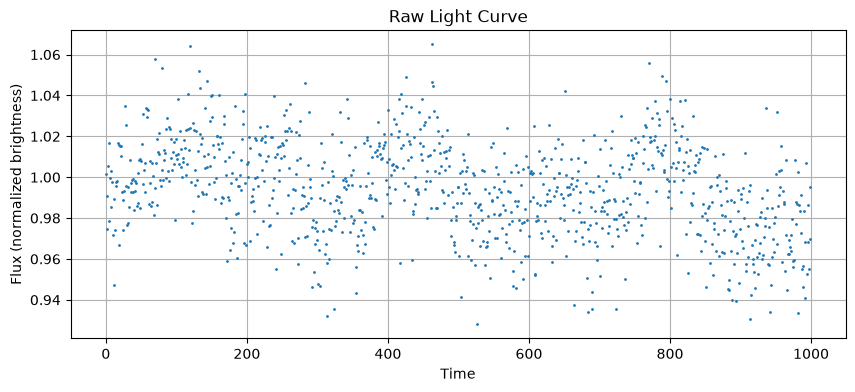

In [25]:
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

plt.plot(lightcurve["time"], lightcurve["flux"], '.', markersize=2)
plt.xlabel("Time")
plt.ylabel("Flux (normalized brightness)")
plt.title("Raw Light Curve")
plt.show()

### _Now we will try to transform each row in a differnt df with labels timeframe and flux_

In [26]:
lightcurves = {}
time_cols = [c for c in df.columns if c.startswith("t_")]

for index in range(len(df)):

    flux_values = df.loc[index, time_cols].values.astype(float)

    temp_df = pd.DataFrame({
        "time": np.arange(len(flux_values)),
        "flux": flux_values
        
    })

    name = f"id_{index}"
    lightcurves[name] = temp_df

In [27]:
lightcurves["id_79"]

,time,flux
0,0,1.013308
1,1,0.965488
2,2,0.997654
3,3,1.012804
4,4,0.995388
...,...,...
995,995,1.049559
996,996,1.011953
997,997,0.991070
998,998,1.027998


### Denoising the signal for 1st row as example

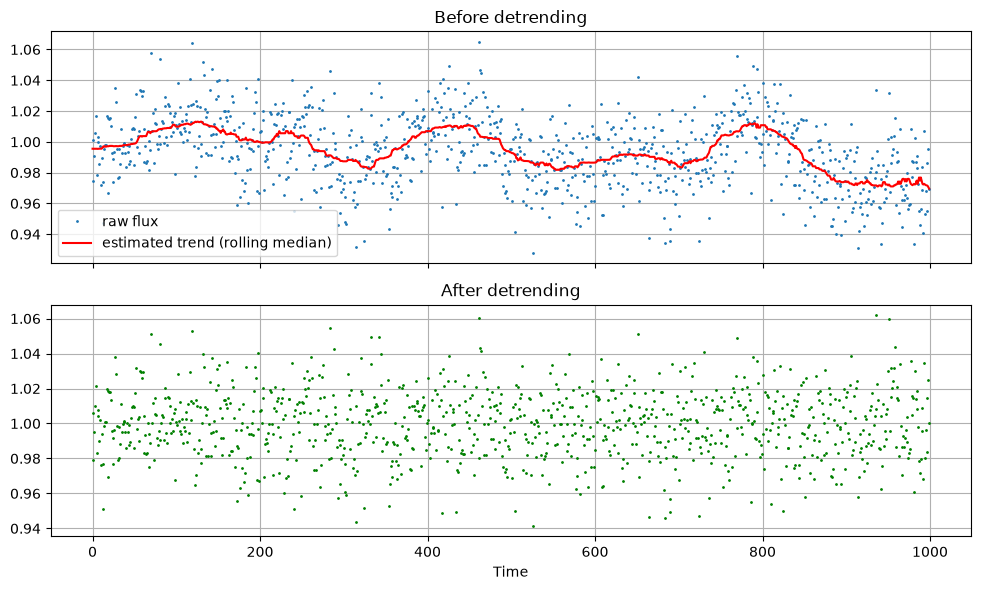

In [40]:
window = 80

rolling_baseline = lightcurve["flux"].rolling(window = window, center= True, min_periods = 1).median()
flux_detrend = lightcurve["flux"] - rolling_baseline + 1

fig, axes = plt.subplots(2, 1, figsize = (10,6), sharex = True)

axes[0].plot(lightcurve["time"], lightcurve["flux"], '.', markersize=2, label="raw flux")
axes[0].plot(lightcurve["time"], rolling_baseline, color='red', label="estimated trend (rolling median)")
axes[0].legend(); axes[0].set_title("Before detrending")

axes[1].plot(lightcurve["time"], flux_detrend, '.', markersize=2, color='green')
axes[1].set_title("After detrending")
axes[1].set_xlabel("Time")
plt.tight_layout()
plt.show()

In [44]:
output_folder = "lightcurves_plot"
os.makedirs(output_folder, exist_ok = True)

plt.ioff()
window = 80

for index in range(500):
    rolling_baseline = lightcurves[f'id_{index}']["flux"].rolling(window = window, center= True, min_periods = 1).median()
    flux_detrend = lightcurves[f'id_{index}']["flux"] - rolling_baseline + 1

    fig, axes = plt.subplots(2, 1, figsize = (10,6), sharex = True)

    axes[0].plot(lightcurves[f'id_{index}']["time"], lightcurves[f'id_{index}']["flux"], '.', markersize=2, label="raw flux")
    axes[0].plot(lightcurves[f'id_{index}']["time"], rolling_baseline, color='red', label="estimated trend (rolling median)")
    axes[0].legend(); axes[0].set_title("Before detrending")

    axes[1].plot(lightcurves[f'id_{index}']["time"], flux_detrend, '.', markersize=2, color='green')
    axes[1].set_title("After detrending")
    axes[1].set_xlabel("Time")


    file_path = os.path.join(output_folder, f"star_id_{index}.png")
    plt.savefig(file_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

plt.ion()
print(f"Done! Successfully saved {lightcurve} light curve images to '{output_folder}/'.")

Done! Successfully saved      time      flux
0       0  1.001467
1       1  0.974578
2       2  0.990939
3       3  1.005583
4       4  1.016866
..    ...       ...
995   995  0.968135
996   996  0.986389
997   997  0.955035
998   998  0.995408
999   999  0.969572

[1000 rows x 2 columns] light curve images to 'lightcurves_plot/'.
